<a href="https://colab.research.google.com/github/Hamtak0/DSP/blob/feature%2Ffft/6610505250_FFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FFT procedure

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time
from math import log2

In [ ]:
def checkpowerof2(n):
    '''
    check if it's power of 2
    '''
    return n > 0 and (n & (n - 1)) == 0

def fix2power(arr):
    '''
    zero-padding
    generating a the power of 2 size array
    input : np.array
    output : np.array with the size of power of 2
    '''
    a = len(arr)
    if not(checkpowerof2(a)):
        b = int(log2(a))
        c = 2**(b+1) - a
        arr = np.concatenate((arr, np.zeros(c, dtype=np.complex256)))
    return arr

def init(arr):
    '''
    initialize np array
    input : array
    output : np.array
    '''
    return np.array(arr, dtype=np.complex256)

In [ ]:
def mean_absolute_error(signal1, signal2):
    '''
    compare an error between 2 signals
    by using mean absolute error
    '''
    mae = 0.0
    if len(signal1) != len(signal2):
        print("Invalid!")
    else:
        # for i in range(len(signal1)):
        #     mae += abs(signal1[i] - signal2[i])
        # mae = mae/len(signal1)
        mae = np.mean(np.abs(signal1 - signal2))
    return mae

## Recursive

In [ ]:
def radix2fft_recursive(arr):
    '''
    radix2 -> divide and conquer
    input : signal in time domain
    output : spectrum in frequency domain
    '''
    if len(arr) <= 1:
        return arr
    even = radix2fft_recursive(arr[::2])
    odd = radix2fft_recursive(arr[1::2])
    n1 = []
    n2 = []
    N = len(arr)
    for i in range(len(even)):
        n1.append(even[i]+np.exp(2*np.pi*-1j*i/N)*odd[i])
        n2.append(even[i]-np.exp(2*np.pi*-1j*i/N)*odd[i])
    return n1+n2

In [ ]:
x = init([1, 2, 3, 4, 5, 6, 7, 8])
# x = [1, 2, 3, 4]
# print(x)
g = fix2power(x)
print(g)
# print(len(g))
z = radix2fft_recursive(g)
for i in range(len(z)):
    print(z[i], end=" ")
print()
print(len(z))

[1.+0.j 2.+0.j 3.+0.j 4.+0.j 5.+0.j 6.+0.j 7.+0.j 8.+0.j]
(36+0j) (-4.000000000000000862+9.656854249492380311j) (-4.000000000000000245+4j) (-4.000000000000000372+1.6568542494923799643j) (-4+0j) (-3.9999999999999996277-1.6568542494923803113j) (-3.999999999999999755-4j) (-3.9999999999999991376-9.656854249492379964j) 
8


In [ ]:
import scipy.fft as fft
y = fft.fft(x)
print(y)
print(len(y))

[36.+0.j         -4.+9.65685425j -4.+4.j         -4.+1.65685425j
 -4.+0.j         -4.-1.65685425j -4.-4.j         -4.-9.65685425j]
8


In [ ]:
mean_absolute_error(z, y)

np.longdouble('3.8507205523581954116e-16')

## Iterative

In [ ]:
def reverse_index(arr):
    '''
    bit reversing
    input : array [1, 2, 3, 4] where 1, 2, 3, 4 is the index
    output : array [1, 3, 2, 4] where the index is switching
    '''
    size = len(arr)
    bitsize = int(log2(size))
    new = np.zeros(size, dtype=np.complex256)
    for i in range(size):
        new[i] = arr[int(format(i, f'0{bitsize}b')[::-1], 2)]
    return (new, size)

reverse_index(init([1, 2, 3, 4, 5, 6, 7, 8]))

(array([1.+0.j, 5.+0.j, 3.+0.j, 7.+0.j, 2.+0.j, 6.+0.j, 4.+0.j, 8.+0.j],
       dtype=complex256),
 8)

In [ ]:
def radix2fft_iterative(arr):
    signal, size = reverse_index(arr)

    '''
    radix2 with iterative approach
    generate from chatgpt
    '''
    N = len(signal)
    block_size = 2
    while block_size <= N:
        half_block = block_size // 2
        twiddle_base = np.exp(-2j * np.pi / block_size)

        for block_start in range(0, N, block_size):
            twiddle = 1
            for pair_offset in range(half_block):
                top = signal[block_start + pair_offset]
                bottom = twiddle * signal[block_start + pair_offset + half_block]

                # Butterfly operation
                signal[block_start + pair_offset] = top + bottom
                signal[block_start + pair_offset + half_block] = top - bottom

                # Update twiddle multiplier
                twiddle *= twiddle_base

        block_size *= 2

    return signal

In [ ]:
x_iter = init([1, 2, 3, 4])
print(radix2fft_iterative(x_iter))

[10.+0.j -2.+2.j -2.+0.j -2.-2.j]


In [ ]:
y_iter = fft.fft(x_iter)
print(y_iter)
print(len(y_iter))

[10.+0.j -2.+2.j -2.+0.j -2.-2.j]
4


# Graph printing

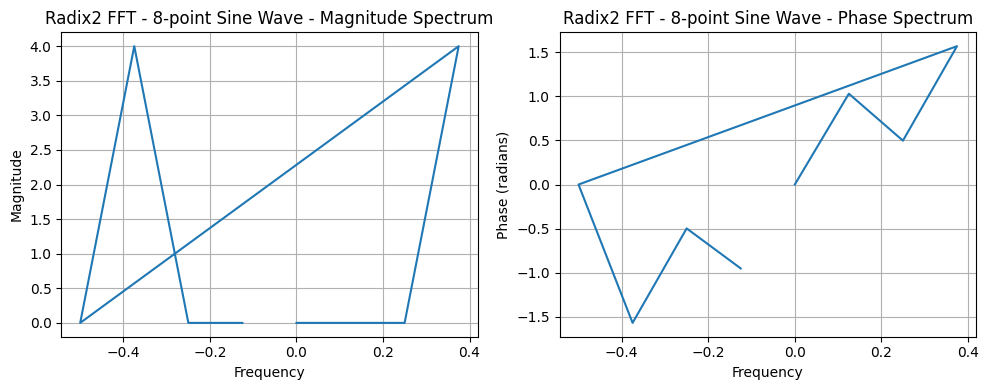

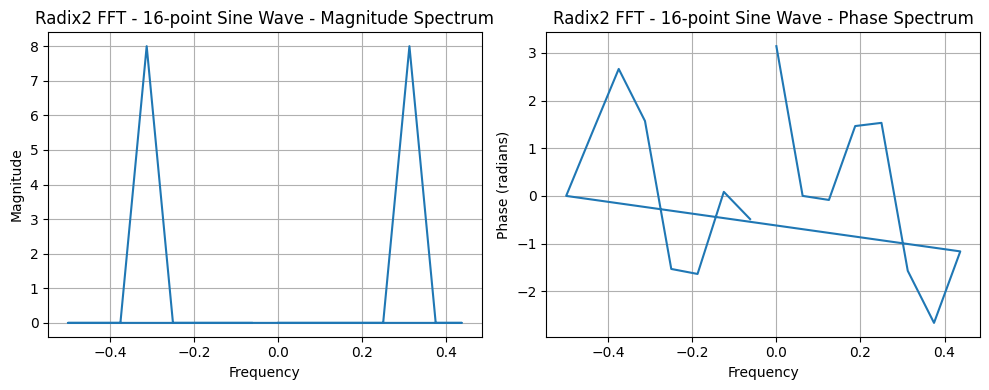

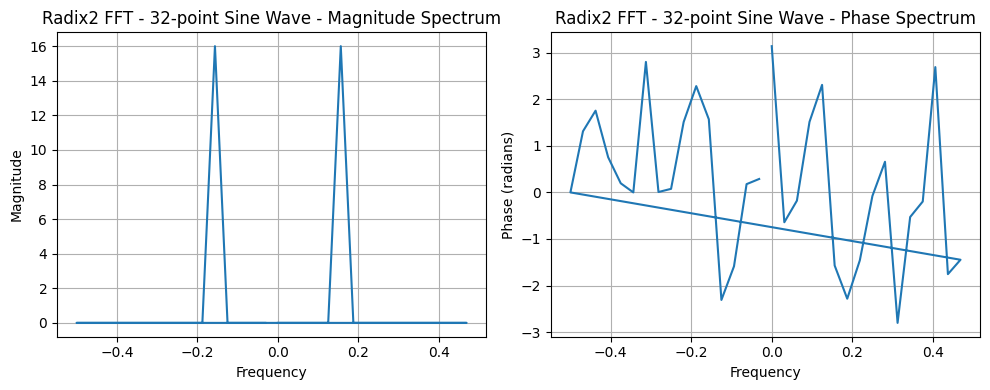

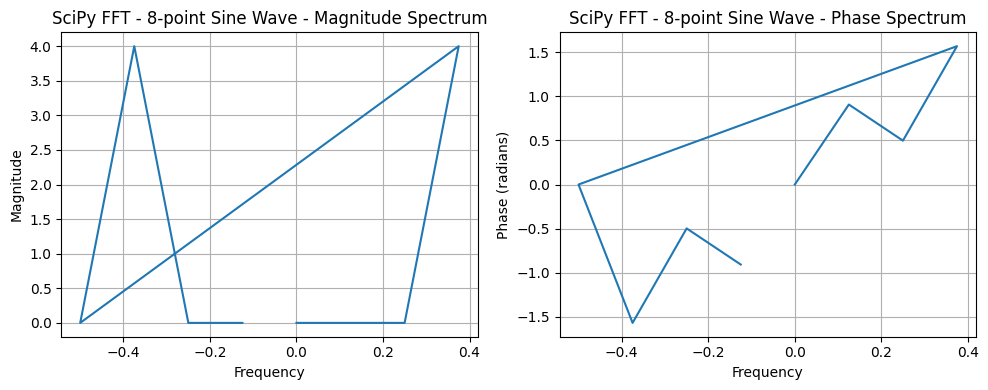

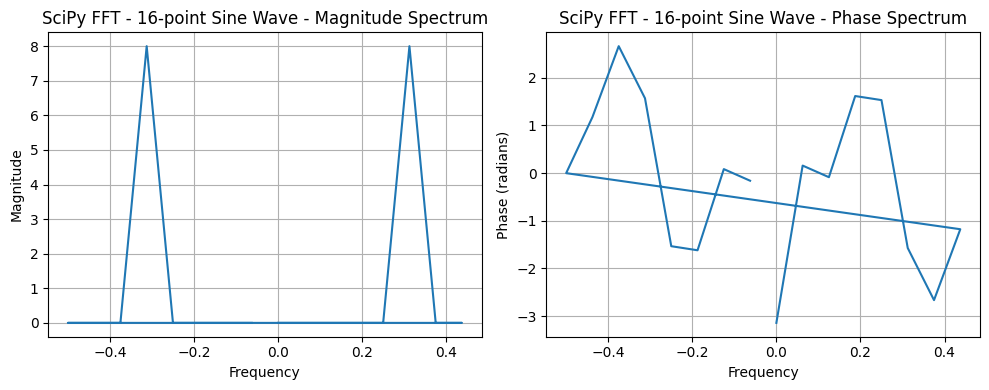

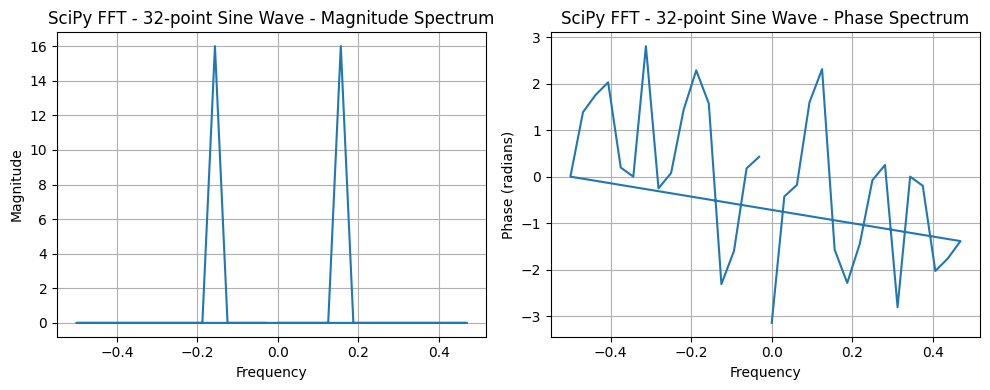

Mean absolute error for 8-point Sine Wave: 1.4163847244119954e-16
Mean absolute error for 16-point Sine Wave: 3.004978357475739e-16
Mean absolute error for 32-point Sine Wave: 4.958971253058511e-16


In [ ]:
'''
generate from gemini
plot magnitude and phrase graph
from sine wave with 8, 16, 32 points
'''

# Create sine waves with 8, 16, and 32 points
freq = 5

time_points_8 = np.linspace(0, 1, 8, endpoint=False)
sine_wave_8 = np.sin(2 * np.pi * freq * time_points_8)

time_points_16 = np.linspace(0, 1, 16, endpoint=False)
sine_wave_16 = np.sin(2 * np.pi * freq * time_points_16)

time_points_32 = np.linspace(0, 1, 32, endpoint=False)
sine_wave_32 = np.sin(2 * np.pi * freq * time_points_32)

# Apply radix2fft_recursive and plot results
def plot_fft_results(signal, title, fft_func):
    fft_result = fft_func(signal)
    frequencies = np.fft.fftfreq(len(signal))

    plt.figure(figsize=(10, 4))

    # Plot magnitude
    plt.subplot(1, 2, 1)
    plt.plot(frequencies, np.abs(fft_result))
    plt.title(f'{title} - Magnitude Spectrum')
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.grid(True)

    # Plot phase
    plt.subplot(1, 2, 2)
    plt.plot(frequencies, np.angle(fft_result))
    plt.title(f'{title} - Phase Spectrum')
    plt.xlabel('Frequency')
    plt.ylabel('Phase (radians)')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Calculate and print errors
def print_fft_error(signal, title):
    fft_radix2 = radix2fft_recursive(signal)
    fft_scipy = fft.fft(signal)
    mae = mean_absolute_error(fft_radix2, fft_scipy)
    print(f"Mean absolute error for {title}: {mae}")


plot_fft_results(sine_wave_8, "Radix2 FFT - 8-point Sine Wave", radix2fft_recursive)
plot_fft_results(sine_wave_16, "Radix2 FFT - 16-point Sine Wave", radix2fft_recursive)
plot_fft_results(sine_wave_32, "Radix2 FFT - 32-point Sine Wave", radix2fft_recursive)

plot_fft_results(sine_wave_8, "SciPy FFT - 8-point Sine Wave", fft.fft)
plot_fft_results(sine_wave_16, "SciPy FFT - 16-point Sine Wave", fft.fft)
plot_fft_results(sine_wave_32, "SciPy FFT - 32-point Sine Wave", fft.fft)

print_fft_error(sine_wave_8, "8-point Sine Wave")
print_fft_error(sine_wave_16, "16-point Sine Wave")
print_fft_error(sine_wave_32, "32-point Sine Wave")

In [ ]:
'''
generate from gemini
'''

# Generate a random 16-point signal
signal_16 = np.random.rand(16)

# Apply radix2fft
start_time = time.time()
fft_radix2_16 = radix2fft_recursive(signal_16)
end_time = time.time()
time_radix2_16 = end_time - start_time

# Apply scipy.fft
start_time = time.time()
fft_scipy_16 = fft.fft(signal_16)
end_time = time.time()
time_scipy_16 = end_time - start_time

print(f"--- 16-point signal ---")
print(f"Radix2 FFT result (first 5 elements): {fft_radix2_16[:5]}")
print(f"SciPy FFT result (first 5 elements): {fft_scipy_16[:5]}")
print(f"Mean absolute error: {mean_absolute_error(fft_radix2_16, fft_scipy_16)}")
print(f"Radix2 FFT time: {time_radix2_16} seconds")
print(f"SciPy FFT time: {time_scipy_16} seconds")

# Generate a random 32-point signal
signal_32 = np.random.rand(32)

# Apply radix2fft
start_time = time.time()
fft_radix2_32 = radix2fft_recursive(signal_32)
end_time = time.time()
time_radix2_32 = end_time - start_time

# Apply scipy.fft
start_time = time.time()
fft_scipy_32 = fft.fft(signal_32)
end_time = time.time()
time_scipy_32 = end_time - start_time

print(f"\n--- 32-point signal ---")
print(f"Radix2 FFT result (first 5 elements): {fft_radix2_32[:5]}")
print(f"SciPy FFT result (first 5 elements): {fft_scipy_32[:5]}")
print(f"Radix2 FFT time: {time_radix2_32} seconds")
print(f"SciPy FFT time: {time_scipy_32} seconds")

--- 16-point signal ---
Radix2 FFT result (first 5 elements): [np.complex128(8.451653384080071+0j), np.complex128(-1.3497563675539446-0.0891491154230592j), np.complex128(0.23280940643111708+0.36240339427145435j), np.complex128(0.6406883385900364-1.0343683741069376j), np.complex128(-2.0723509578760115-0.17803737156399446j)]
SciPy FFT result (first 5 elements): [ 8.45165338-0.j         -1.34975637-0.08914912j  0.23280941+0.36240339j
  0.64068834-1.03436837j -2.07235096-0.17803737j]
Mean absolute error: 1.551631417530309e-16
Radix2 FFT time: 0.00024247169494628906 seconds
SciPy FFT time: 0.0001900196075439453 seconds

--- 32-point signal ---
Radix2 FFT result (first 5 elements): [np.complex128(17.82107525069094+0j), np.complex128(-0.3128712626014981+0.09245116973071127j), np.complex128(-0.3695340347535396+1.5188949565210188j), np.complex128(-1.505472561106931-0.5945790636600449j), np.complex128(-0.6233048341319614+0.02046773256934009j)]
SciPy FFT result (first 5 elements): [17.82107525-0.


--- 256-point signals ---
Radix2 Recursive FFT time (random): 0.003430604934692383 seconds
Radix2 Recursive FFT time (sine): 0.0035066604614257812 seconds
Radix2 Iterative FFT time (random): 0.0012247562408447266 seconds
Radix2 Iterative FFT time (sine): 0.0011789798736572266 seconds
SciPy FFT time (random): 0.00010609626770019531 seconds
SciPy FFT time (sine): 2.1457672119140625e-05 seconds
Radix2 Recursive FFT error (random): 1.4898353411137452e-15
Radix2 Iterative FFT error (random): 7.045146859412726e-15
Radix2 Recursive FFT error (sine): 1.5577980367151983e-15
Radix2 Iterative FFT error (sine): 3.9193336416879035e-15

--- 512-point signals ---
Radix2 Recursive FFT time (random): 0.0068972110748291016 seconds
Radix2 Recursive FFT time (sine): 0.0074536800384521484 seconds
Radix2 Iterative FFT time (random): 0.0034089088439941406 seconds
Radix2 Iterative FFT time (sine): 0.0027396678924560547 seconds
SciPy FFT time (random): 0.00011706352233886719 seconds
SciPy FFT time (sine): 4.3

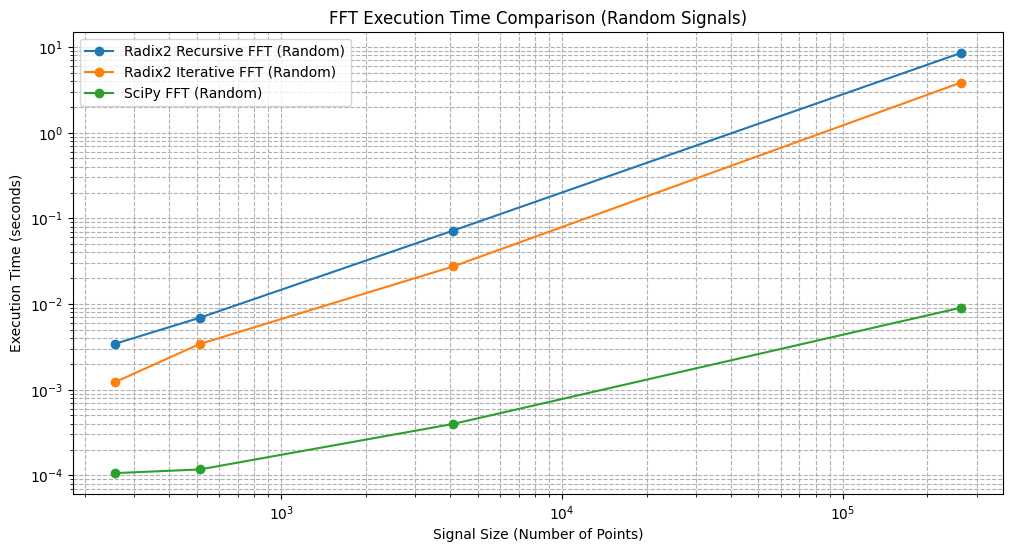

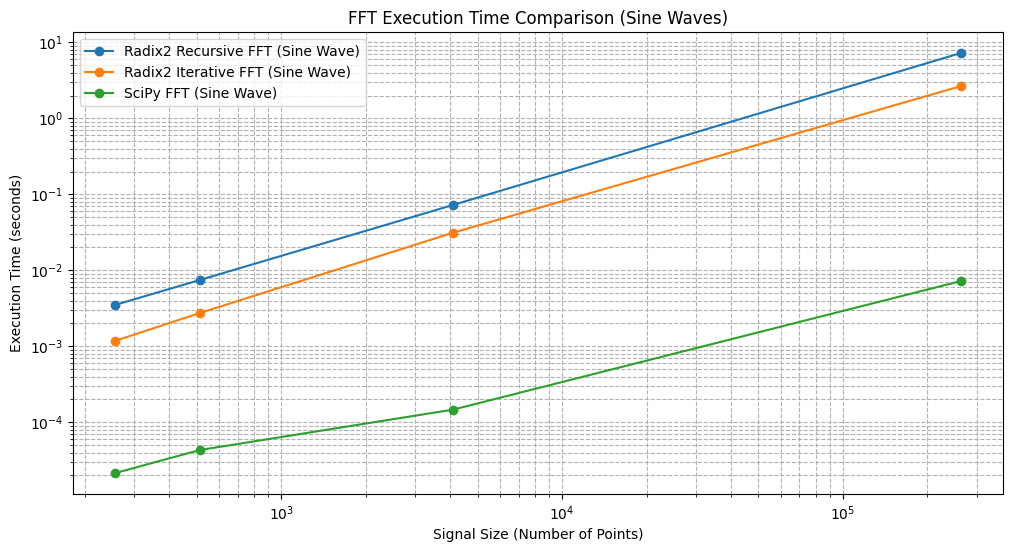

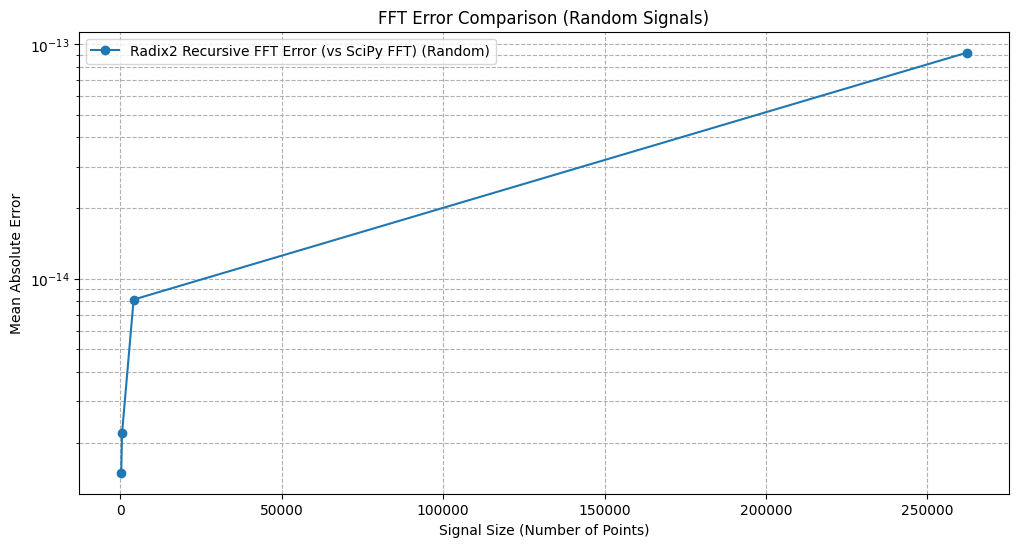

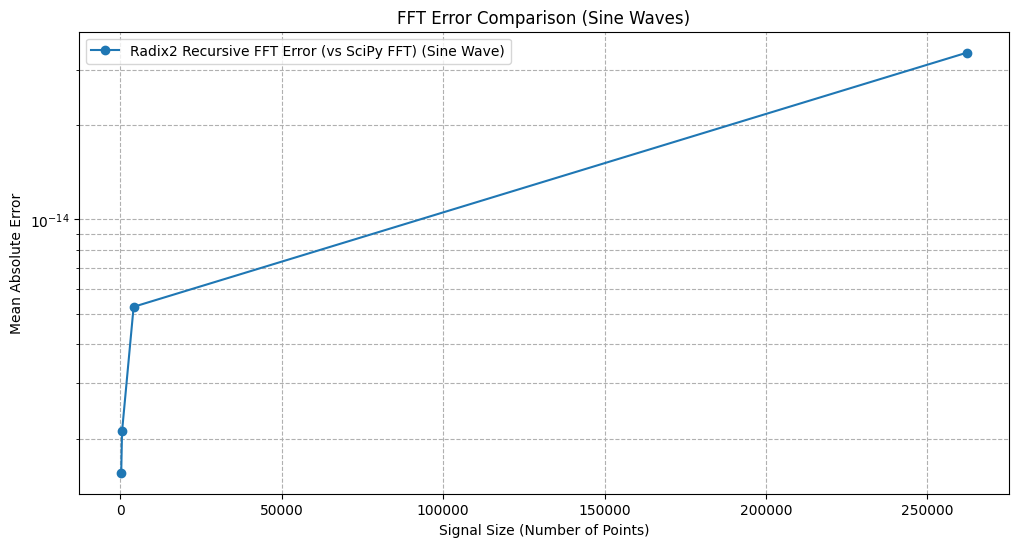

In [ ]:
'''
generate from gemini
plot graph of time and error comparison
'''

# Powers of 2 to test
powers_of_2 = [2**8, 2**9, 2**12, 2**18]

time_radix2_recursive_random = []
time_radix2_iterative_random = []
time_scipy_random = []

time_radix2_recursive_sine = []
time_radix2_iterative_sine = []
time_scipy_sine = []

error_radix2_recursive_random = []
error_radix2_iterative_random = []

error_radix2_recursive_sine = []
error_radix2_iterative_sine = []


signal_sizes = []

for n_points in powers_of_2:
  print(f"\n--- {n_points}-point signals ---")

  # Generate a random signal
  random_signal = np.random.rand(n_points)
  signal_sizes.append(n_points)

  # Generate a sine wave
  time_points = np.linspace(0, 1, n_points, endpoint=False)
  sine_wave = np.sin(2 * np.pi * 5 * time_points)


  # Apply radix2fft_recursive to random signal
  start_time = time.time()
  fft_radix2_rec_random = radix2fft_recursive(random_signal)
  end_time = time.time()
  time_radix2_recursive_random.append(end_time - start_time)
  print(f"Radix2 Recursive FFT time (random): {time_radix2_recursive_random[-1]} seconds")

  # Apply radix2fft_recursive to sine wave
  start_time = time.time()
  fft_radix2_rec_sine = radix2fft_recursive(sine_wave)
  end_time = time.time()
  time_radix2_recursive_sine.append(end_time - start_time)
  print(f"Radix2 Recursive FFT time (sine): {time_radix2_recursive_sine[-1]} seconds")


  # Apply radix2fft_iterative to random signal
  start_time = time.time()
  fft_radix2_iter_random = radix2fft_iterative(random_signal)
  end_time = time.time()
  time_radix2_iterative_random.append(end_time - start_time)
  print(f"Radix2 Iterative FFT time (random): {time_radix2_iterative_random[-1]} seconds")

  # Apply radix2fft_iterative to sine wave
  start_time = time.time()
  fft_radix2_iter_sine = radix2fft_iterative(sine_wave)
  end_time = time.time()
  time_radix2_iterative_sine.append(end_time - start_time)
  print(f"Radix2 Iterative FFT time (sine): {time_radix2_iterative_sine[-1]} seconds")


  # Apply scipy.fft to random signal
  start_time = time.time()
  fft_scipy_random = fft.fft(random_signal)
  end_time = time.time()
  time_scipy_random.append(end_time - start_time)
  print(f"SciPy FFT time (random): {time_scipy_random[-1]} seconds")

  # Apply scipy.fft to sine wave
  start_time = time.time()
  fft_scipy_sine = fft.fft(sine_wave)
  end_time = time.time()
  time_scipy_sine.append(end_time - start_time)
  print(f"SciPy FFT time (sine): {time_scipy_sine[-1]} seconds")

  # Calculate and store errors
  error_radix2_recursive_random.append(mean_absolute_error(fft_radix2_rec_random, fft_scipy_random))
  error_radix2_iterative_random.append(mean_absolute_error(fft_radix2_iter_random, fft_scipy_random))

  error_radix2_recursive_sine.append(mean_absolute_error(fft_radix2_rec_sine, fft_scipy_sine))
  error_radix2_iterative_sine.append(mean_absolute_error(fft_radix2_iter_sine, fft_scipy_sine))

  print(f"Radix2 Recursive FFT error (random): {error_radix2_recursive_random[-1]}")
  print(f"Radix2 Iterative FFT error (random): {error_radix2_iterative_random[-1]}")
  print(f"Radix2 Recursive FFT error (sine): {error_radix2_recursive_sine[-1]}")
  print(f"Radix2 Iterative FFT error (sine): {error_radix2_iterative_sine[-1]}")


# Plot the time comparison for random signals
plt.figure(figsize=(12, 6))
plt.plot(signal_sizes, time_radix2_recursive_random, marker='o', label='Radix2 Recursive FFT (Random)')
plt.plot(signal_sizes, time_radix2_iterative_random, marker='o', label='Radix2 Iterative FFT (Random)')
plt.plot(signal_sizes, time_scipy_random, marker='o', label='SciPy FFT (Random)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Signal Size (Number of Points)')
plt.ylabel('Execution Time (seconds)')
plt.title('FFT Execution Time Comparison (Random Signals)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# Plot the time comparison for sine waves
plt.figure(figsize=(12, 6))
plt.plot(signal_sizes, time_radix2_recursive_sine, marker='o', label='Radix2 Recursive FFT (Sine Wave)')
plt.plot(signal_sizes, time_radix2_iterative_sine, marker='o', label='Radix2 Iterative FFT (Sine Wave)')
plt.plot(signal_sizes, time_scipy_sine, marker='o', label='SciPy FFT (Sine Wave)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Signal Size (Number of Points)')
plt.ylabel('Execution Time (seconds)')
plt.title('FFT Execution Time Comparison (Sine Waves)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# Plot the error comparison for random signals
plt.figure(figsize=(12, 6))
plt.plot(signal_sizes, error_radix2_recursive_random, marker='o', label='Radix2 Recursive FFT Error (vs SciPy FFT) (Random)')
plt.yscale('log')
plt.xlabel('Signal Size (Number of Points)')
plt.ylabel('Mean Absolute Error')
plt.title('FFT Error Comparison (Random Signals)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# Plot the error comparison for sine waves
plt.figure(figsize=(12, 6))
plt.plot(signal_sizes, error_radix2_recursive_sine, marker='o', label='Radix2 Recursive FFT Error (vs SciPy FFT) (Sine Wave)')
plt.yscale('log')
plt.xlabel('Signal Size (Number of Points)')
plt.ylabel('Mean Absolute Error')
plt.title('FFT Error Comparison (Sine Waves)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()